# NB05 — H2 Test: Joint Anaerobic Toolkit

**Hypothesis**
- **H0**: Within the clay cohort, deep-confined isolates show no greater enrichment of the literature-defined anaerobic toolkit (Wood–Ljungdahl + group 1 [NiFe]-hydrogenase + dissimilatory sulfate reduction) than shallow agricultural-clay isolates.
- **H1**: Deep-confined isolates jointly carry all three modules at higher rates — testing Bagnoud (2016) Opalinus and Beaver & Neufeld (2024) depth-enriched hydrogenase predictions.

**Method**: per-genome `toolkit_score` (0–3 modules complete); Cochran–Armitage trend test across depth classes; per-marker Fisher's exact with BH-FDR; **within-phylum tests for Bacillota_B confound control**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

anchor = pd.read_parquet(DATA_DIR / 'genome_features.parquet')
baseline = pd.read_parquet(DATA_DIR / 'baseline_features.parquet')
all_features = pd.concat([anchor, baseline], ignore_index=True)
for c in ['checkm_completeness']:
    all_features[c] = pd.to_numeric(all_features[c], errors='coerce')

qc = all_features[(all_features['checkm_completeness'] >= 80)].copy()
print(f'qc cohort sizes: {qc["cohort_class"].value_counts().to_dict()}')

qc cohort sizes: {'soil_baseline': 140, 'anchor_shallow': 30, 'unclassified': 18, 'anchor_deep': 9, 'excluded': 2}


## 1. Toolkit score by cohort (descriptive)

In [2]:
summary_overall = qc.groupby('cohort_class').agg(
    n=('genome_id', 'count'),
    WL=('WL_complete', 'mean'),
    NiFe=('NiFe_complete', 'mean'),
    SR=('SR_complete', 'mean'),
    mean_toolkit=('toolkit_score', 'mean'),
    pct_with_3=('toolkit_score', lambda x: (x == 3).mean()),
).round(3)
summary_overall

,n,WL,NiFe,SR,mean_toolkit,pct_with_3
cohort_class,,,,,,
anchor_deep,9,0.556,0.778,0.556,1.889,0.556
anchor_shallow,30,0.000,0.033,0.000,0.033,0.000
excluded,2,0.000,0.000,0.000,0.000,0.000
soil_baseline,140,0.107,0.250,0.036,0.393,0.021
unclassified,18,0.000,0.000,0.000,0.000,0.000


## 2. Cochran–Armitage trend test

Ordered depth classes: surface → shallow → deep / deep_rock. Test whether toolkit_score (or each marker) shows a monotone trend.

In [3]:
# Map ordering: 0 = soil_baseline, 1 = surface clay, 2 = deep clay
def depth_rank(row):
    if row['cohort_class'] == 'soil_baseline': return 0
    if row['cohort_class'] == 'anchor_shallow': return 1
    if row['cohort_class'] == 'anchor_deep': return 2
    return np.nan
qc['depth_rank'] = qc.apply(depth_rank, axis=1)
qc_o = qc.dropna(subset=['depth_rank']).copy()
qc_o['depth_rank'] = qc_o['depth_rank'].astype(int)

# Spearman rank correlation between depth_rank and per-marker presence (0/1)
trend_rows = []
for marker in ['WL_complete','NiFe_complete','SR_complete','IR_complete','Nif_complete']:
    x = qc_o['depth_rank'].values
    y = qc_o[marker].astype(int).values
    if y.std() == 0:
        trend_rows.append(dict(marker=marker, rho=np.nan, p_value=np.nan, n=len(y), pos_rate=float(y.mean())))
        continue
    rho, p = stats.spearmanr(x, y)
    trend_rows.append(dict(marker=marker, rho=float(rho), p_value=float(p), n=len(y), pos_rate=float(y.mean())))
trend_df = pd.DataFrame(trend_rows)
trend_df['p_BH'] = multipletests(trend_df['p_value'].fillna(1).values, method='fdr_bh')[1]
trend_df.round(4)


,marker,rho,p_value,n,pos_rate,p_BH
0,WL_complete,0.0633,0.4002,179,0.1117,0.5003
1,NiFe_complete,-0.0077,0.9180,179,0.2402,0.9180
2,SR_complete,0.2145,0.0039,179,0.0559,0.0098
3,IR_complete,0.1661,0.0263,179,0.2570,0.0438
4,Nif_complete,0.2752,0.0002,179,0.1844,0.0010


## 3. Fisher's exact: anchor_deep vs soil_baseline per marker

Direct two-by-two: clay-deep vs soil baseline, per marker.

In [4]:
fisher_rows = []
for marker in ['WL_complete','NiFe_complete','SR_complete','IR_complete','Nif_complete']:
    a_deep = qc[qc['cohort_class'] == 'anchor_deep'][marker]
    a_base = qc[qc['cohort_class'] == 'soil_baseline'][marker]
    table = [[a_deep.sum(), len(a_deep) - a_deep.sum()],
             [a_base.sum(), len(a_base) - a_base.sum()]]
    odds, p = stats.fisher_exact(table, alternative='two-sided')
    fisher_rows.append(dict(marker=marker, n_deep=len(a_deep), pos_deep=int(a_deep.sum()),
                            n_base=len(a_base), pos_base=int(a_base.sum()),
                            odds_ratio=odds, p_value=p))
fisher_df = pd.DataFrame(fisher_rows)
fisher_df['p_BH'] = multipletests(fisher_df['p_value'].fillna(1).values, method='fdr_bh')[1]
fisher_df.round(4)

,marker,n_deep,pos_deep,n_base,pos_base,odds_ratio,p_value,p_BH
0,WL_complete,9,5,140,15,10.4167,0.0024,0.0040
1,NiFe_complete,9,7,140,35,10.5000,0.0021,0.0040
2,SR_complete,9,5,140,5,33.7500,0.0000,0.0002
3,IR_complete,9,1,140,30,0.4583,0.6856,0.6856
4,Nif_complete,9,4,140,18,5.4222,0.0277,0.0346


## 4. Within-phylum control (Bacillota_B is the key phylum)

In [5]:
phylum_rows = []
for phylum in qc['tax_phylum'].dropna().unique():
    sub = qc[qc['tax_phylum'] == phylum]
    for marker in ['WL_complete','NiFe_complete','SR_complete','IR_complete','Nif_complete']:
        deep = sub[sub['cohort_class'] == 'anchor_deep'][marker]
        base = sub[sub['cohort_class'] == 'soil_baseline'][marker]
        if len(deep) < 2 or len(base) < 5:
            continue
        table = [[deep.sum(), len(deep) - deep.sum()],
                 [base.sum(), len(base) - base.sum()]]
        try:
            odds, p = stats.fisher_exact(table, alternative='two-sided')
        except Exception:
            continue
        phylum_rows.append(dict(phylum=phylum, marker=marker,
                                n_deep=len(deep), pos_deep=int(deep.sum()),
                                n_base=len(base), pos_base=int(base.sum()),
                                odds_ratio=odds, p_value=p))
phylum_df = pd.DataFrame(phylum_rows)
if len(phylum_df) > 0:
    phylum_df['p_BH'] = multipletests(phylum_df['p_value'].fillna(1).values, method='fdr_bh')[1]
phylum_df.round(4)

,phylum,marker,n_deep,pos_deep,n_base,pos_base,odds_ratio,p_value,p_BH
0,p__Pseudomonadota,WL_complete,2,0,47,0,NaN,1.0000,1.0000
1,p__Pseudomonadota,NiFe_complete,2,1,47,12,2.9167,0.4643,1.0000
2,p__Pseudomonadota,SR_complete,2,0,47,1,0.0000,1.0000,1.0000
3,p__Pseudomonadota,IR_complete,2,1,47,29,0.6207,1.0000,1.0000
4,p__Pseudomonadota,Nif_complete,2,0,47,7,0.0000,1.0000,1.0000
5,p__Bacteroidota,WL_complete,2,0,16,0,NaN,1.0000,1.0000
6,p__Bacteroidota,NiFe_complete,2,1,16,2,7.0000,0.3137,1.0000
7,p__Bacteroidota,SR_complete,2,0,16,0,NaN,1.0000,1.0000
8,p__Bacteroidota,IR_complete,2,0,16,0,NaN,1.0000,1.0000
9,p__Bacteroidota,Nif_complete,2,0,16,1,0.0000,1.0000,1.0000


## 5. Visualization

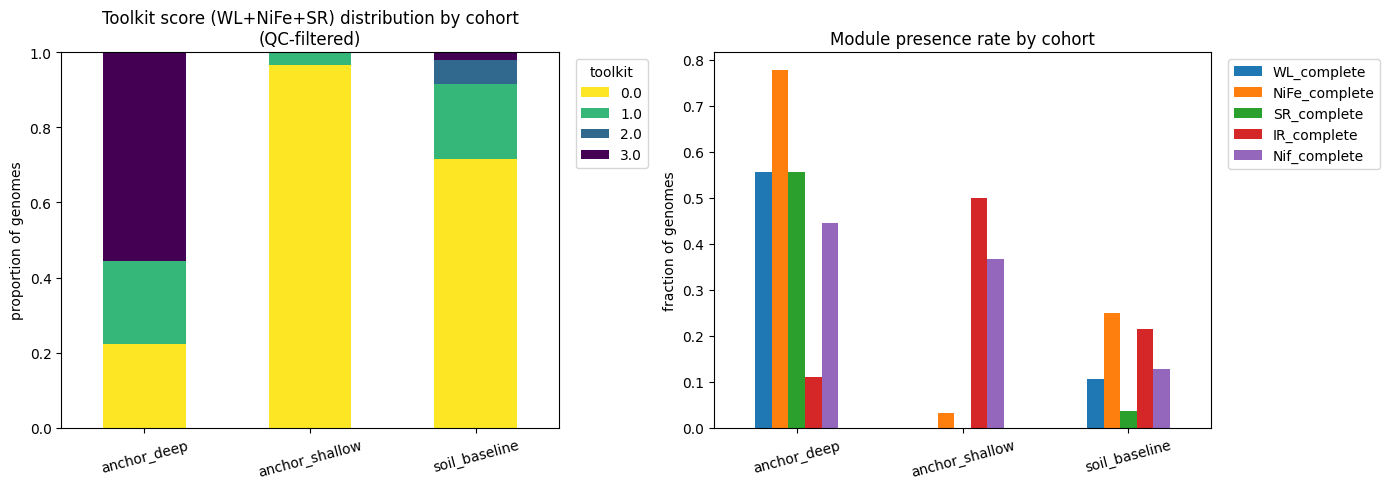

saved: ../figures/h2_toolkit_by_cohort.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['anchor_deep', 'anchor_shallow', 'soil_baseline']
data = qc[qc['cohort_class'].isin(order)].copy()
tk = data.groupby(['cohort_class','toolkit_score']).size().reset_index(name='n')
tk_pivot = tk.pivot(index='cohort_class', columns='toolkit_score', values='n').fillna(0)
tk_pivot = tk_pivot.div(tk_pivot.sum(axis=1), axis=0)
tk_pivot = tk_pivot.reindex(order)
tk_pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis_r')
axes[0].set_title('Toolkit score (WL+NiFe+SR) distribution by cohort\n(QC-filtered)')
axes[0].set_ylabel('proportion of genomes')
axes[0].set_xlabel('')
axes[0].set_xticklabels(order, rotation=15)
axes[0].legend(title='toolkit', bbox_to_anchor=(1.02,1), loc='upper left')

# Per-marker rates
marker_rates = data.groupby('cohort_class')[['WL_complete','NiFe_complete','SR_complete','IR_complete','Nif_complete']].mean().reindex(order)
marker_rates.plot(kind='bar', ax=axes[1])
axes[1].set_title('Module presence rate by cohort')
axes[1].set_ylabel('fraction of genomes')
axes[1].set_xlabel('')
axes[1].set_xticklabels(order, rotation=15)
axes[1].legend(bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
out_fig = FIG_DIR / 'h2_toolkit_by_cohort.png'
plt.savefig(out_fig, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved: {out_fig}')

## 6. Save results

In [7]:
trend_df.to_csv(DATA_DIR / 'h2_trend_test.tsv', sep='\t', index=False)
fisher_df.to_csv(DATA_DIR / 'h2_fisher_deep_vs_baseline.tsv', sep='\t', index=False)
phylum_df.to_csv(DATA_DIR / 'h2_within_phylum.tsv', sep='\t', index=False)
summary_overall.to_csv(DATA_DIR / 'h2_cohort_summary.tsv', sep='\t')
print('saved h2_*.tsv')
print('\n=== summary ===')
summary_overall

saved h2_*.tsv

=== summary ===


,n,WL,NiFe,SR,mean_toolkit,pct_with_3
cohort_class,,,,,,
anchor_deep,9,0.556,0.778,0.556,1.889,0.556
anchor_shallow,30,0.000,0.033,0.000,0.033,0.000
excluded,2,0.000,0.000,0.000,0.000,0.000
soil_baseline,140,0.107,0.250,0.036,0.393,0.021
unclassified,18,0.000,0.000,0.000,0.000,0.000
